<div style="background-color: #e8f5e9; border-left: 6px solid #2e7d32; padding: 15px; margin-bottom: 20px; border-radius: 4px;">
    <h1 style="color: #1b5e20; margin: 0; font-family: sans-serif;">Exploratory Data Analysis (EDA) & Spectral Separability</h1>
    <p style="margin: 5px 0 0 0; color: #37474f; font-size: 1.1em;">
        Descriptive statistics, multi-sensor spectral signature profiling, and ANOVA/Tukey HSD separability analysis.
    </p>
</div>

In [ ]:
# 1. Standard Library Imports
import os
import gc
import math
import json
from pathlib import Path
from itertools import combinations
import xml.etree.ElementTree as ET

# 2. Third-Party Scientific & Data Processing Imports
import cv2
import openpyxl
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.transforms import Affine2D
from matplotlib_scalebar.scalebar import ScaleBar
from scipy import stats
from scipy.spatial import distance
import statsmodels.api as sm
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# 3. GIS & Geospatial Analysis Imports
import fiona
import geopandas as gpd
import rasterio
from rasterio import features
from rasterio.mask import mask
from rasterio.features import geometry_mask
from rasterio.windows import from_bounds
from rasterio.plot import show, reshape_as_image
from rasterio.warp import calculate_default_transform, reproject, Resampling
from rasterstats import zonal_stats

# 4. Machine Learning & Model Evaluation Imports
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score, 
    balanced_accuracy_score, recall_score
)
from skimage.feature import graycomatrix, graycoprops
from skimage.registration import phase_cross_correlation

# 5. Environment & Output Visualization Configuration
import warnings
import nest_asyncio
import dataframe_image as dfi

# System overrides & setups
warnings.filterwarnings('ignore')
nest_asyncio.apply()
fiona.drvsupport.supported_drivers['KML'] = 'rw'

c:\Users\48755625H\AppData\Local\anaconda3\envs\esa-project-1\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.4.3)/charset_normalizer (3.4.6) doesn't match a supported version!
  warnings.warn(


In [ ]:
#BASE
path_base = Path(os.getcwd()).parent
#SHAPEFILES
shp_pln = Path(path_base) / "06_QGIS/23-05-2024_QGis_MaízLaPoveda/2024-05-23_LaPoveda_Maiz-Sorgo_Patches_PlnScope_EPSG32630.shp"
shp_wv2 = Path(path_base) / "06_QGIS/23-05-2024_QGis_MaízLaPoveda/2024-05-23_LaPoveda_Maiz-Sorgo_Patches_wv-02_EsquinaII_EPSG32630.shp"
shp_bounds = Path(path_base) / "06_QGIS/23-05-2024_QGis_MaízLaPoveda/2024_bounds_Maiz-Sorgo_plot.shp"
shp_bounds_wv2 = Path(path_base) / "06_QGIS/23-05-2024_QGis_MaízLaPoveda/2024_bounds_Maiz-Sorgo_plot_wv2.shp"
#RASTER-IMAGERY
ortho_path = Path(path_base) / "01_img_data/drone/DJI Matrice 300 RTK/2024-06-13_MaízPoveda_RGB_20m_Orthomosaic.tif"
out_pln = Path(path_base) / "01_img_data/satellite/PlanetScope/20240613_111156_44_24fc_3B_AnalyticMS_SR_8b_harmonized_BOA.tif"
out_pan_wv2 = Path(path_base) / "01_img_data/satellite/worldview-2/24JUN11104156-P3DS-050518203010_01_P001_BOA.TIF"
out_ms_wv2 = Path(path_base) / "01_img_data/satellite/worldview-2/24JUN11104156-M3DS-050518203010_01_P001_BOA.TIF"
#PANSHARPENING
pansharp_BROV = Path(path_base) / "01_img_data/satellite/worldview-2/24JUN11104156-M3DS-050518203010_01_P001_BOA_PAN_simple_brovey.TIF"
pansharp_MEAN = Path(path_base) / "01_img_data/satellite/worldview-2/24JUN11104156-M3DS-050518203010_01_P001_BOA_PAN_simple_mean.TIF"
pansharp_ESRI = Path(path_base) / "01_img_data/satellite/worldview-2/24JUN11104156-M3DS-050518203010_01_P001_BOA_PAN_esri.TIF"
pansharp_GS = Path(path_base) / "01_img_data/satellite/worldview-2/24JUN11104156-M3DS-050518203010_01_P001_BOA_PAN_gram_schmidt.TIF"
#DATASETS-RODALES
path_dfA = Path(path_base) / "07_datasets/Dataset_1_Planet_3m.xlsx"
path_dfB = Path(path_base) / "07_datasets/Dataset_2_WV2_MS_2m.xlsx"
path_dfC = Path(path_base) / "07_datasets/Dataset_3_WV2_Pansharp_GS_05m.xlsx"

**Comparativa pixeles de centroide y píxeles de borde incluidos en el cálculo espectral medio de cada rodal por tamaño**

- ANÁLISIS A (Pansharpening WV2) -> Rodales viables retenidos: 246 (Conserva clase 'Low')
- ANÁLISIS B (WV2 vs Planet) -> Rodales viables retenidos: 121 (Clase 'Low' descartada por resolución de 3m)

In [12]:
def contar_pixeles_rodal(geom, src):
    """
    Calcula cuántos píxeles contribuyen a la media (centroide dentro) 
    y cuántos son solo de borde (tocados pero centroide fuera).
    """
    # 1. Obtener la caja envolvente (bounding box) del polígono con un margen de 1 píxel
    res = src.res[0]
    minx, miny, maxx, maxy = geom.bounds
    ventana = from_bounds(minx - res, miny - res, maxx + res, maxy + res, src.transform)
    ventana = ventana.round_lengths().round_offsets()
    
    # Transformación espacial local para esa ventanita
    win_transform = src.window_transform(ventana)
    out_shape = (ventana.height, ventana.width)
    
    if out_shape[0] <= 0 or out_shape[1] <= 0:
        return 0, 0
        
    # 2. Máscara 1: Solo píxeles cuyo centro cae DENTRO del polígono (all_touched=False)
    mask_centros = features.geometry_mask(
        [geom], out_shape=out_shape, transform=win_transform, 
        all_touched=False, invert=True
    )
    
    # 3. Máscara 2: TODOS los píxeles que son tocados por el polígono (all_touched=True)
    mask_tocados = features.geometry_mask(
        [geom], out_shape=out_shape, transform=win_transform, 
        all_touched=True, invert=True
    )
    
    # 4. Cálculos
    pixeles_centro = mask_centros.sum()
    pixeles_totales = mask_tocados.sum()
    pixeles_borde = pixeles_totales - pixeles_centro
    
    return pixeles_centro, pixeles_borde

def analizar_cobertura_pixeles(dict_imagenes, col_clase='Patch_size'):
    """
    Itera sobre las imágenes y sus shapefiles correspondientes para calcular
    el área media y la distribución de píxeles por clase.
    """
    resultados_totales = []
    
    for nombre, config in dict_imagenes.items():
        print(f"Procesando: {nombre}...")
        ruta_raster = config['raster']
        ruta_shp = config['shp']
        
        # Cargar shapefile
        gdf = gpd.read_file(ruta_shp)
        # Calcular área geométrica real en m2
        gdf['Area_m2'] = gdf.geometry.area
        
        # Abrir imagen para leer su cuadrícula espacial
        with rasterio.open(ruta_raster) as src:
            # Aplicar la función a cada polígono
            conteos = gdf.geometry.apply(lambda g: contar_pixeles_rodal(g, src))
            
            # Separar los resultados en dos columnas
            gdf['Px_Centro (Útiles)'] = [c[0] for c in conteos]
            gdf['Px_Borde (Descarte)'] = [c[1] for c in conteos]
        
        # Agrupar por clase para sacar las medias
        resumen = gdf.groupby(col_clase).agg({
            'Area_m2': 'mean',
            'Px_Centro (Útiles)': 'mean',
            'Px_Borde (Descarte)': 'mean'
        }).reset_index()
        
        resumen['Imagen'] = nombre
        resultados_totales.append(resumen)
        
    # Unir todos los resultados en un solo DataFrame
    df_final = pd.concat(resultados_totales, ignore_index=True)
    
    # Reordenar columnas para una lectura más limpia
    df_final = df_final[['Imagen', col_clase, 'Area_m2', 'Px_Centro (Útiles)', 'Px_Borde (Descarte)']]
    
    # Redondear a 2 decimales para que sea legible
    return df_final.round(2)

# ==========================================
# EJECUCIÓN
# ==========================================
# Diccionario con tus 3 escenarios vinculando cada imagen a su shapefile correcto
configuracion = {
    'PlanetScope MS (3m)': {
        'raster': out_pln, # Ruta a tu TIF de Planet
        'shp': shp_pln   # Ruta a tu SHP de Planet
    },
    'WorldView-2 MS (2m)': {
        'raster': out_ms_wv2,     # Ruta a tu TIF original de WV2
        'shp': shp_wv2   # Ruta a tu SHP de WV2
    },
    'WorldView-2 pansharp (0.5m)': {
        'raster': pansharp_GS, # Ruta a un TIF pansharpened (ej. Gram-Schmidt)
        'shp': shp_wv2         # WV2 comparte el mismo SHP
    }
}

df_cobertura = analizar_cobertura_pixeles(configuracion)
orden_logico = ['High', 'Medium', 'Low', 'no-sorgo']
df_cobertura['Patch_size'] = pd.Categorical(
    df_cobertura['Patch_size'], 
    categories=orden_logico, 
    ordered=True)
df_cobertura = df_cobertura.sort_values(by=['Imagen', 'Patch_size']).reset_index(drop=True)
print("\n📊 TABLA DE COBERTURA: Píxeles Centrales vs Borde por Clase")
print("-" * 80)
display(df_cobertura)

Procesando: PlanetScope MS (3m)...
Procesando: WorldView-2 MS (2m)...
Procesando: WorldView-2 pansharp (0.5m)...

📊 TABLA DE COBERTURA: Píxeles Centrales vs Borde por Clase
--------------------------------------------------------------------------------


,Imagen,Patch_size,Area_m2,Px_Centro (Útiles),Px_Borde (Descarte)
0,PlanetScope MS (3m),High,55.22,6.12,8.25
1,PlanetScope MS (3m),Medium,2.12,0.22,2.28
2,PlanetScope MS (3m),Low,0.20,0.02,1.18
3,PlanetScope MS (3m),no-sorgo,119.85,13.22,10.40
4,WorldView-2 MS (2m),High,55.22,13.91,12.19
5,WorldView-2 MS (2m),Medium,2.12,0.48,3.24
6,WorldView-2 MS (2m),Low,0.20,0.05,1.27
7,WorldView-2 MS (2m),no-sorgo,119.85,29.91,15.76
8,WorldView-2 pansharp (0.5m),High,55.22,220.62,64.14
9,WorldView-2 pansharp (0.5m),Medium,2.12,8.55,10.66


🎨 Generando Gráfica de Porcentajes de Pureza...


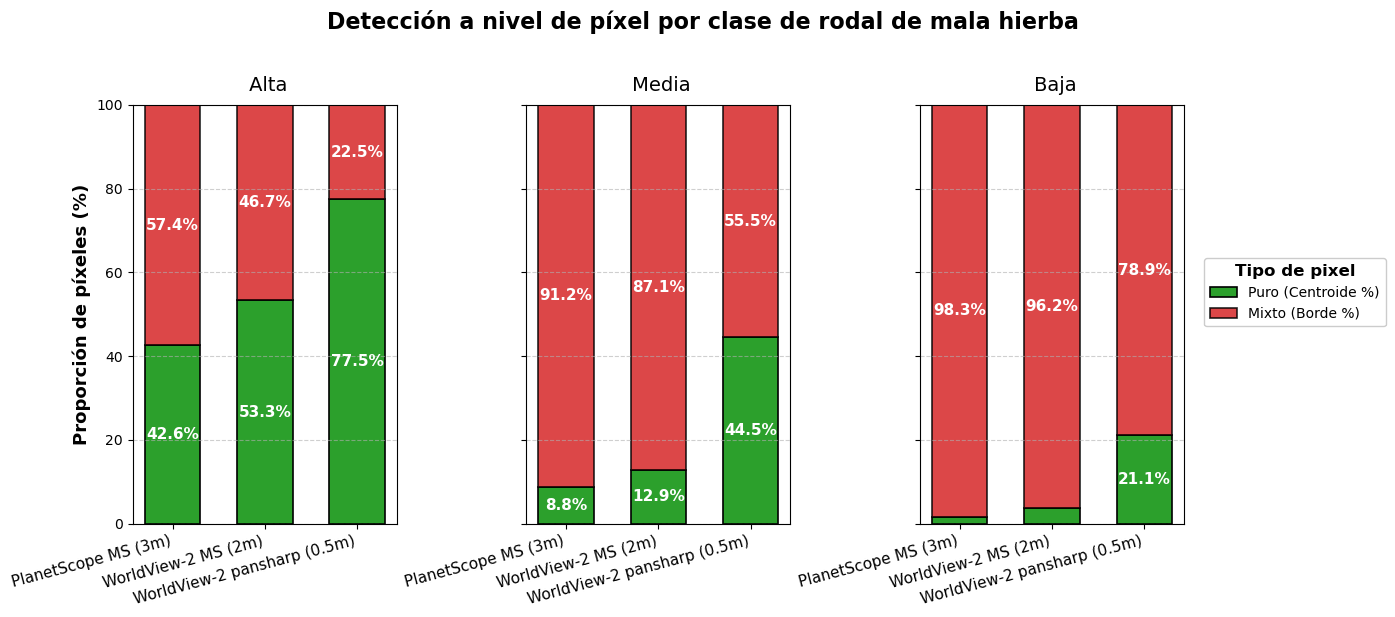

In [14]:
def graficar_porcentajes_cobertura(df_cobertura, col_clase='Patch_size'):
    print("🎨 Generando Gráfica de Porcentajes de Pureza...")
    
    # 1. Copiar y preparar porcentajes
    df = df_cobertura.copy()
    df['Total_Px'] = df['Px_Centro (Útiles)'] + df['Px_Borde (Descarte)']
    
    df['% Centro (Puro)'] = np.where(df['Total_Px'] > 0, 
                                     (df['Px_Centro (Útiles)'] / df['Total_Px']) * 100, 0)
    df['% Borde (Mixto)'] = np.where(df['Total_Px'] > 0, 
                                     (df['Px_Borde (Descarte)'] / df['Total_Px']) * 100, 100)
    
    clases = [c for c in df[col_clase].unique() if c != 'no-sorgo']
    imagenes = df['Imagen'].unique()
    
    # 2. Configurar figura
    fig, axes = plt.subplots(1, len(clases), figsize=(14, 6), sharey=True)
    fig.suptitle('Detección a nivel de píxel por clase de rodal de mala hierba', 
                 fontsize=16, fontweight='bold', y=1.02)
    
    color_puro = '#2ca02c'   
    color_mixto = '#d62728'  
    
    x_pos = np.arange(len(imagenes))
    width = 0.6
    
    for i, clase in enumerate(clases):
        ax = axes[i] if len(clases) > 1 else axes
        
        datos_clase = df[df[col_clase] == clase].set_index('Imagen').reindex(imagenes)
        pct_puro = datos_clase['% Centro (Puro)'].fillna(0).values
        pct_mixto = datos_clase['% Borde (Mixto)'].fillna(100).values
        
        barras_p = ax.bar(x_pos, pct_puro, width, label='Puro (Centroide %)', 
                          color=color_puro, edgecolor='black', linewidth=1.2)
        
        barras_m = ax.bar(x_pos, pct_mixto, width, bottom=pct_puro, label='Mixto (Borde %)', 
                          color=color_mixto, edgecolor='black', linewidth=1.2, alpha=0.85)
        
        # Textos interiores
        for j in range(len(x_pos)):
            if pct_puro[j] > 5:
                ax.text(x_pos[j], pct_puro[j]/2, f"{pct_puro[j]:.1f}%", 
                        ha='center', va='center', color='white', fontweight='bold', fontsize=11)
            
            if pct_mixto[j] > 5:
                ax.text(x_pos[j], pct_puro[j] + (pct_mixto[j]/2), f"{pct_mixto[j]:.1f}%", 
                        ha='center', va='center', color='white', fontweight='bold', fontsize=11)
        
        # Estética
        # Diccionario de traducción
        traduccion = {'High': 'Alta', 'Medium': 'Media', 'Low': 'Baja'}
        clase_es = traduccion.get(clase, clase)
        ax.set_title(f" {clase_es}", fontsize=14, pad=10)
        ax.set_xticks(x_pos)
        ax.set_xticklabels(imagenes, rotation=15, ha='right', fontsize=11)
        ax.set_ylim(0, 100)
        ax.grid(axis='y', linestyle='--', alpha=0.6)
        
        if i == 0:
            ax.set_ylabel('Proporción de píxeles (%)', fontsize=13, fontweight='bold')
            
        if pct_puro[0] == 0:
            ax.text(x_pos[0], 105, "¡100% Ruido!", color='red', ha='center', fontsize=10, fontweight='bold')

    # =========================================================================
    # 🚨 LA MAGIA DE LA LEYENDA AQUÍ 🚨
    # Se ancla EXCLUSIVAMENTE al último gráfico (axes[-1]) y se escupe hacia la derecha
    # =========================================================================
    axes[-1].legend(title='Tipo de pixel', 
                    title_fontproperties={'weight':'bold', 'size':12},
                    loc='upper left', 
                    bbox_to_anchor=(1.05, 0.65), 
                    framealpha=1)

    # El tight_layout reajusta los márgenes para que la leyenda quepa en la imagen exportada
    plt.tight_layout()
    plt.show()

# Ejecución
graficar_porcentajes_cobertura(df_cobertura)

**Analisis exploratorio de los datos (EDA)**
- **WorldView-2:** 1,Coastal Blue  2,Blue  3,Green   4,Yellow  5,Red  6,Red Edge  7,Near-Infrared 1  8,Near-Infrared 2
- ANOTA LAS LONGITUDES DE ONDA DE CADA BANDA
- **PlanetScope:** 1,Coastal Blue  2,Blue  3,Green I   4,Green II  5,Yellow  6,Red  7,Red Edge   8,Near-Infrared
- ANOTA LAS LONGITUDES DE ONDA DE CADA BANDA

In [5]:
dfA = pd.read_excel(path_dfA)
dfB = pd.read_excel(path_dfB)
dfC = pd.read_excel(path_dfC)

In [25]:
dfC

,ID_patch,Patch_size,Area_m2,WV2_05m_GS_B1,WV2_05m_GS_B2,WV2_05m_GS_B3,WV2_05m_GS_B4,WV2_05m_GS_B5,WV2_05m_GS_B6,WV2_05m_GS_B7,WV2_05m_GS_B8,WV2_05m_GS_NDVI,WV2_05m_GS_NDRE
0,p-0001,Low,0.111,0.025835,0.046789,0.078352,0.114421,0.169036,0.193203,0.310058,0.367917,0.294353,0.232196
1,p-0002,Low,0.040,0.025788,0.047489,0.078936,0.116569,0.172883,0.194338,0.307111,0.368486,0.279646,0.224894
2,p-0003,Low,0.793,0.025555,0.047747,0.078097,0.116923,0.172681,0.190801,0.297293,0.358940,0.265146,0.218179
3,p-0004,Low,0.064,0.018062,0.035129,0.061596,0.087276,0.127857,0.192498,0.343989,0.399265,0.458055,0.282375
4,p-0005,Low,0.688,0.018189,0.034346,0.060723,0.085611,0.124563,0.190830,0.345008,0.401909,0.469461,0.287733
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1876,p-1877,no-sorgo,489.383,0.017641,0.033006,0.060714,0.084154,0.121310,0.183056,0.322547,0.376595,0.453383,0.275890
1877,p-1878,no-sorgo,275.455,0.021698,0.040006,0.069290,0.100723,0.149587,0.184710,0.296914,0.350233,0.329958,0.232970
1878,p-1879,no-sorgo,182.938,0.022993,0.041558,0.071889,0.104884,0.156326,0.187340,0.294793,0.347749,0.306941,0.222869
1879,p-1880,no-sorgo,212.915,0.021028,0.038512,0.067556,0.096436,0.143487,0.182215,0.294934,0.346651,0.345435,0.236235


🚀 INICIANDO EDA DE ALTO IMPACTO...

📊 1. BALANCE DE CLASES (TARGET):
Patch_size
Low         84.6
Medium       9.6
High         3.4
no-sorgo     2.4
Name: proportion, dtype: float64 %
--------------------------------------------------
🔗 2. ALERTA DE MULTICOLINEALIDAD (> 0.90 Pearson):
⚠️ Hay 2 variables redundantes.
Ejemplos: ['PS_3m_NDVI', 'PS_3m_NDRE']...
--------------------------------------------------

🗺️ GENERANDO MAPA DE CALOR DE CORRELACIÓN...


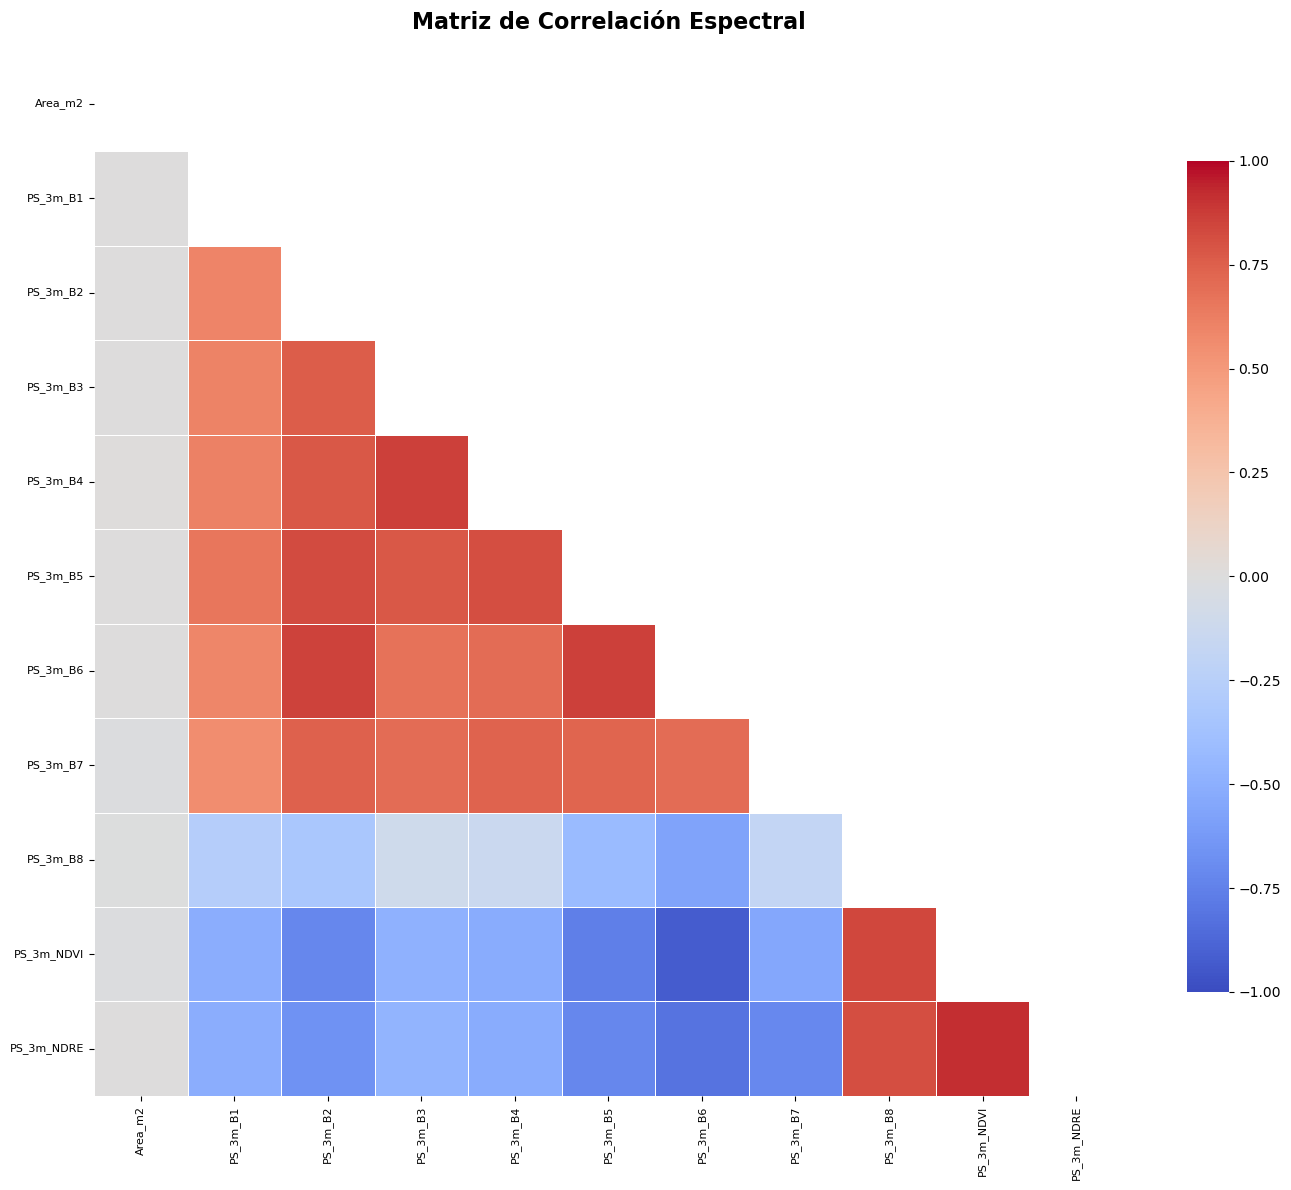


🏆 3. TOP 6 VARIABLES MÁS IMPORTANTES (Random Forest):
Area_m2       0.8170
PS_3m_B7      0.0247
PS_3m_B8      0.0220
PS_3m_NDVI    0.0202
PS_3m_NDRE    0.0188
PS_3m_B6      0.0178
PS_3m_B5      0.0176
PS_3m_B3      0.0176
PS_3m_B4      0.0154
PS_3m_B2      0.0147
dtype: float64

🎨 4. GENERANDO GRÁFICOS DE SEPARABILIDAD (Solo el Top 6)...


C:\Users\48755625H\AppData\Local\Temp\ipykernel_18900\2098008822.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=col_target, y=var, ax=axes[fila, col], palette='Set2')
C:\Users\48755625H\AppData\Local\Temp\ipykernel_18900\2098008822.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=col_target, y=var, ax=axes[fila, col], palette='Set2')
C:\Users\48755625H\AppData\Local\Temp\ipykernel_18900\2098008822.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=col_target, y=var, ax=axes[fila, col], palette='Se

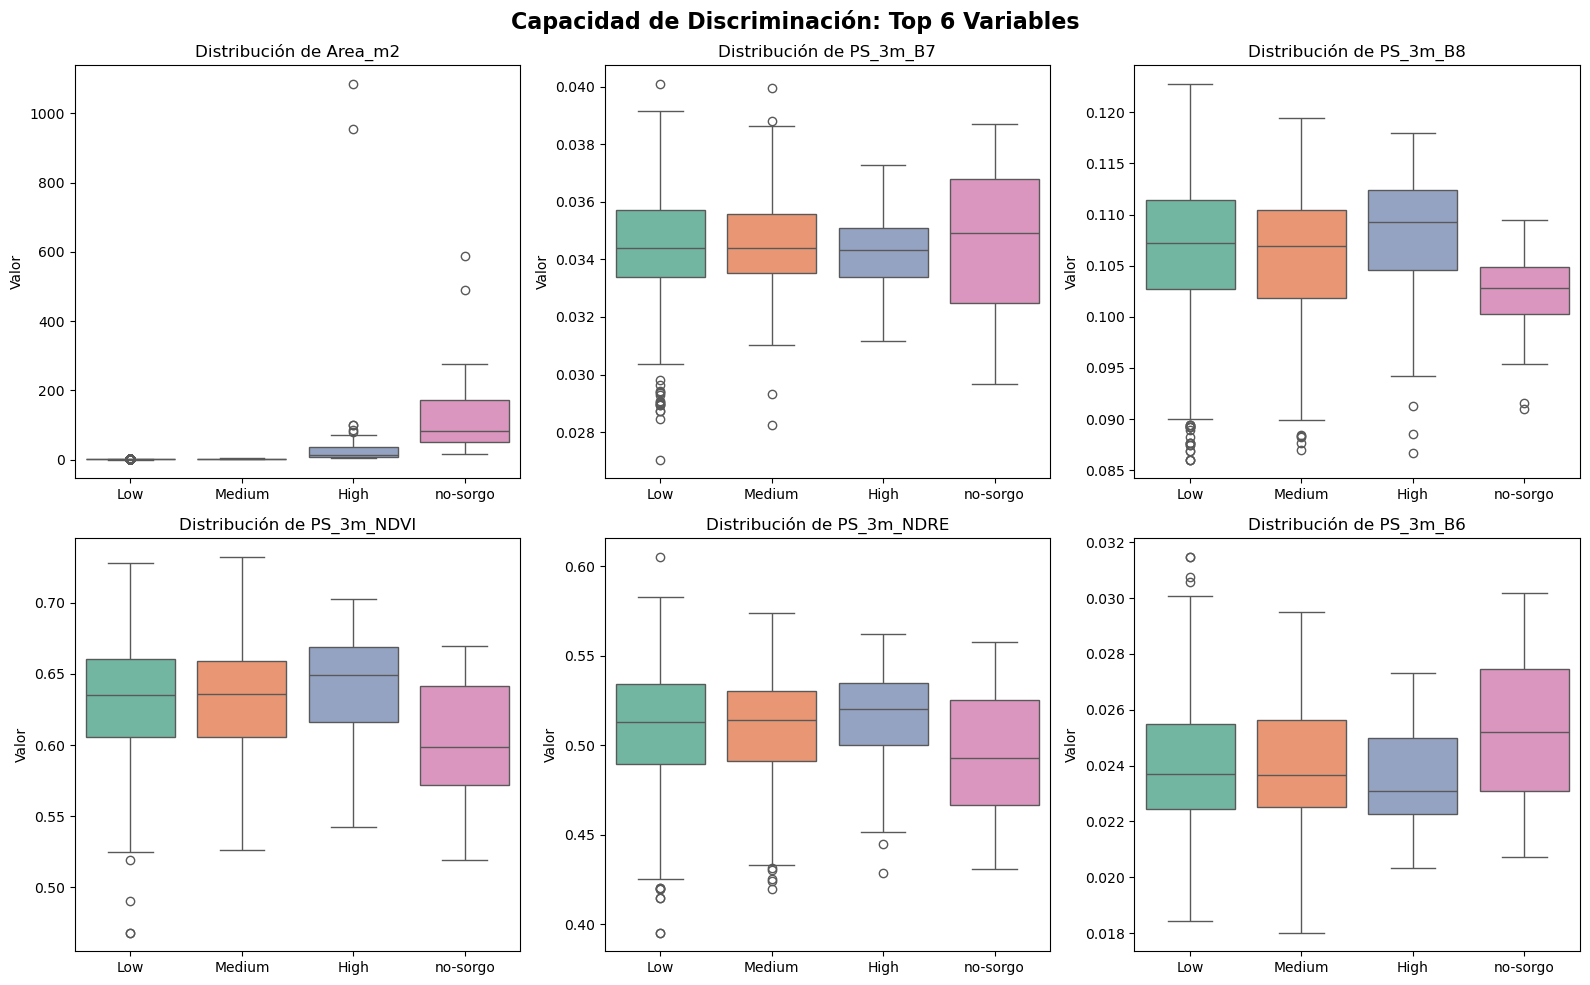

In [7]:
def eda_clasificacion_rapido(df, col_target='Patch_size'):
    print("🚀 INICIANDO EDA DE ALTO IMPACTO...\n")
    
    # Separar variables numéricas (tus bandas e índices)
    X = df.select_dtypes(include=[np.number]).dropna(axis=1, how='all')
    y = df[col_target]
    
    # ---------------------------------------------------------
    # 1. SALUD DE LOS DATOS Y BALANCE DE CLASES
    # ---------------------------------------------------------
    print("📊 1. BALANCE DE CLASES (TARGET):")
    print(y.value_counts(normalize=True).round(3) * 100, "%")
    print("-" * 50)
    
    # ---------------------------------------------------------
    # 2. FILTRO DE REDUNDANCIA (ALTA CORRELACIÓN)
    # ---------------------------------------------------------
    print("🔗 2. ALERTA DE MULTICOLINEALIDAD (> 0.90 Pearson):")
    matriz_corr = X.corr()
    matriz_corr_abs = matriz_corr.abs()
    
    upper = matriz_corr_abs.where(np.triu(np.ones(matriz_corr_abs.shape), k=1).astype(bool))
    vars_a_eliminar = [col for col in upper.columns if any(upper[col] > 0.90)]
    
    if vars_a_eliminar:
        print(f"⚠️ Hay {len(vars_a_eliminar)} variables redundantes.")
        print(f"Ejemplos: {vars_a_eliminar[:10]}...") 
    else:
        print("✅ No hay variables altamente correlacionadas.")
    print("-" * 50)
    
    # ---------------------------------------------------------
    # NUEVO: 2.5 GRÁFICA DE LA MATRIZ DE CORRELACIÓN
    # ---------------------------------------------------------
    print("\n🗺️ GENERANDO MAPA DE CALOR DE CORRELACIÓN...")
    plt.figure(figsize=(14, 12))
    
    # Crear una máscara para ocultar el triángulo superior
    mask = np.triu(np.ones_like(matriz_corr, dtype=bool))
    
    # Generar el heatmap con colores frío-calor (azul negativo, rojo positivo)
    sns.heatmap(matriz_corr, mask=mask, cmap='coolwarm', vmin=-1, vmax=1, 
                annot=False, linewidths=0.5, cbar_kws={"shrink": .8})
    
    plt.title('Matriz de Correlación Espectral', fontsize=16, fontweight='bold', pad=20)
    plt.xticks(fontsize=8, rotation=90)
    plt.yticks(fontsize=8)
    plt.tight_layout()
    plt.show()

    # ---------------------------------------------------------
    # 3. SELECCIÓN POR FUERZA BRUTA (RANDOM FOREST)
    # ---------------------------------------------------------
    print("\n🏆 3. TOP 6 VARIABLES MÁS IMPORTANTES (Random Forest):")
    X_rf = X.fillna(0) 
    
    rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    rf.fit(X_rf, y)
    
    importancias = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
    top_6_vars = importancias.head(6).index
    print(importancias.head(10).round(4))
    
    # ---------------------------------------------------------
    # 4. VISUALIZACIÓN DEL TOP 6 (BOXPLOTS)
    # ---------------------------------------------------------
    print("\n🎨 4. GENERANDO GRÁFICOS DE SEPARABILIDAD (Solo el Top 6)...")
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    fig.suptitle('Capacidad de Discriminación: Top 6 Variables', fontsize=16, fontweight='bold')
    
    for i, var in enumerate(top_6_vars):
        fila, col = i // 3, i % 3
        sns.boxplot(data=df, x=col_target, y=var, ax=axes[fila, col], palette='Set2')
        axes[fila, col].set_title(f"Distribución de {var}")
        axes[fila, col].set_xlabel("")
        axes[fila, col].set_ylabel("Valor")
    
    plt.tight_layout()
    plt.show()

eda_clasificacion_rapido(dfA, col_target='Patch_size')

In [19]:
import nest_asyncio # <-- La clave para que no falle el motor web en Jupyter
# Activar el parche para permitir la captura web exacta
nest_asyncio.apply()

# =====================================================================
# 0. DICCIONARIOS DE METADATOS (Bandas y Traducciones)
# =====================================================================
bandas_planet = {
    'B1': 'Coastal Blue\n(431-452 nm)', 'B2': 'Blue\n(465-515 nm)', 
    'B3': 'Green I\n(513-549 nm)', 'B4': 'Green II\n(547-583 nm)', 
    'B5': 'Yellow\n(600-620 nm)', 'B6': 'Red\n(650-680 nm)', 
    'B7': 'Red Edge\n(697-713 nm)', 'B8': 'NIR\n(845-885 nm)', 
    'NDVI': 'NDVI', 'NDRE': 'NDRE'
}

bandas_wv2 = {
    'B1': 'Coastal Blue\n(400-450 nm)', 'B2': 'Blue\n(450-510 nm)', 
    'B3': 'Green\n(510-580 nm)', 'B4': 'Yellow\n(585-625 nm)', 
    'B5': 'Red\n(630-690 nm)', 'B6': 'Red Edge\n(705-745 nm)', 
    'B7': 'NIR 1\n(770-895 nm)', 'B8': 'NIR 2\n(860-1040 nm)', 
    'NDVI': 'NDVI', 'NDRE': 'NDRE'
}

mapa_clases = {'no-sorgo': 'Nula', 'Low': 'Baja', 'Medium': 'Media', 'High': 'Alta'}
orden_clases = ['Nula', 'Baja', 'Media', 'Alta']

# =====================================================================
# 1. MOTOR ESTADÍSTICO
# =====================================================================
def asignar_letras_tukey(df, col_valor, col_clase='Patch_size', alpha=0.05):
    # 1. Obtener medias ordenadas
    medias = df.groupby(col_clase)[col_valor].mean().sort_values(ascending=False)
    clases_ordenadas = medias.index.tolist()
    
    # 2. Ejecutar Tukey HSD con el alpha dinámico
    tukey = pairwise_tukeyhsd(endog=df[col_valor], groups=df[col_clase], alpha=alpha)
    df_tukey = pd.DataFrame(data=tukey._results_table.data[1:], columns=tukey._results_table.data[0])
    
    # Inicializar letras
    letras = {clase: '' for clase in clases_ordenadas}
    letra_actual = ord('a')
    grupos_actuales = [[clases_ordenadas[0]]]
    letras[clases_ordenadas[0]] = chr(letra_actual)
    
    for i in range(1, len(clases_ordenadas)):
        clase_eval = clases_ordenadas[i]
        compartido = False
        
        for idx, grupo in enumerate(grupos_actuales):
            # [CORRECCIÓN]: Comprobamos si no hay rechazo con NINGUNO de los miembros del grupo
            diferente_de_alguno = False
            for miembro in grupo:
                c1, c2 = sorted([miembro, clase_eval])
                rechazo = df_tukey[(df_tukey['group1'] == c1) & (df_tukey['group2'] == c2)]['reject'].values[0]
                if rechazo:
                    diferente_de_alguno = True
                    break
            
            # Si no es significativamente diferente de ninguno, comparte el grupo (y la letra)
            if not diferente_de_alguno:
                letras[clase_eval] += chr(ord('a') + idx)
                grupo.append(clase_eval)
                compartido = True
                
        # Si es diferente a todos los grupos existentes, creamos un nuevo grupo
        if not compartido:
            letra_actual += 1
            grupos_actuales.append([clase_eval])
            letras[clase_eval] += chr(letra_actual)
            
    resultados_str = {}
    for clase in clases_ordenadas:
        resultados_str[clase] = f"{medias[clase]:.4f} {letras[clase]}"
    return resultados_str


def crear_tabla_transpuesta(df, prefijo, dict_bandas, col_clase='Patch_size', alpha=0.001):
    columnas_espectrales = [c for c in df.columns if c.startswith(prefijo) and c not in ['Patch_size', 'ID_patch', 'Area_m2']]
    
    datos_tabla = {}
    for col in columnas_espectrales:
        nombre_banda_crudo = col.replace(f"{prefijo}_", "")
        nombre_publicacion = dict_bandas.get(nombre_banda_crudo, nombre_banda_crudo)
        datos_tabla[nombre_publicacion] = asignar_letras_tukey(df, col, col_clase)
        
    df_tabla = pd.DataFrame(datos_tabla)
    df_tabla.rename(index=mapa_clases, inplace=True)
    orden_presente = [c for c in orden_clases if c in df_tabla.index]
    df_tabla = df_tabla.reindex(orden_presente)
    df_tabla.index.name = "Nivel de Infestación"
    return df_tabla

# =====================================================================
# 2. ESTILO VISUAL HTML/CSS
# =====================================================================
def aplicar_estilo_transpuesto(df, titulo_sensor):
    df_estilo = df.copy()
    df_estilo.columns = pd.MultiIndex.from_product([[titulo_sensor], df_estilo.columns])
    
    return df_estilo.style\
        .set_properties(**{
            'text-align': 'center', 
            'padding': '12px 15px', # Aumentado el padding para que respire más como en pantalla
            'white-space': 'pre-wrap'
        })\
        .set_table_styles([
            dict(selector='th.col_heading.level0', props=[('background-color', '#1f3a52'), 
                                                          ('color', 'white'), 
                                                          ('font-size', '16px'),
                                                          ('text-align', 'center'),
                                                          ('border', '1px solid white')]),
            dict(selector='th.col_heading.level1', props=[('background-color', '#34495e'), 
                                                          ('color', 'white'),
                                                          ('font-size', '13px'),
                                                          ('text-align', 'center'),
                                                          ('border', '1px solid white')]),
            dict(selector='th.row_heading', props=[('background-color', '#ecf0f1'),
                                                   ('color', '#2c3e50'),
                                                   ('font-weight', 'bold'),
                                                   ('text-align', 'left'),
                                                   ('font-size', '13px'),
                                                   ('border-right', '2px solid #2c3e50')]),
            dict(selector='td', props=[('border', '1px solid #ddd')])
        ])

# =====================================================================
# 3. EXPORTACIÓN EXACTA (Usando el motor web nativo)
# =====================================================================
print("🧪 Generando tablas y exportando imagen fiel a la pantalla...")
os.makedirs("08_resultados", exist_ok=True)

# 1. PlanetScope
dfi.export(estilo_planet, "08_resultados/Tabla_ANOVA_Planet_3m_Transpuesta.png", 
           dpi=300, table_conversion="chrome")
print("\n--- 1. TABLA PLANETSCOPE (3m) ---")
display(estilo_planet)

# 2. WV2 (2m)
dfi.export(estilo_wv2_2m, "08_resultados/Tabla_ANOVA_WV2_2m_Transpuesta.png", 
           dpi=300, table_conversion="chrome")
print("\n--- 2. TABLA WORLDVIEW-2 (2m) ---")
display(estilo_wv2_2m)

# 3. WV2 Pansharp (0.5m)
dfi.export(estilo_wv2_gs, "08_resultados/Tabla_ANOVA_WV2_05m_GS_Transpuesta.png", 
           dpi=300, table_conversion="chrome")
print("\n--- 3. TABLA WORLDVIEW-2 PANSHARP GS (0.5m) ---")
display(estilo_wv2_gs)

print("\n✅ ¡Tablas guardadas con la estética idéntica a la de la pantalla!")

🧪 Generando tablas y exportando imagen fiel a la pantalla...

--- 1. TABLA PLANETSCOPE (3m) ---



--- 2. TABLA WORLDVIEW-2 (2m) ---



--- 3. TABLA WORLDVIEW-2 PANSHARP GS (0.5m) ---



✅ ¡Tablas guardadas con la estética idéntica a la de la pantalla!


In [26]:
# 1. Elegimos una variable de ejemplo (cambia 'WV2_Red' por una columna real de tu df)
columna_test = 'WV2_05m_GS_NDVI' 
# 2. Imprimir estadísticas descriptivas básicas por grupo (N, Media, Desviación Estándar)
print("--- ESTADÍSTICOS DESCRIPTIVOS ---")
descriptivos = dfC.groupby('Patch_size')[columna_test].agg(['count', 'mean', 'std'])
print(descriptivos)
print("\n")
# 3. Ejecutar Tukey directamente con statsmodels usando alpha = 0.001
print("--- RESULTADOS DEL TEST DE TUKEY (alpha = 0.001) ---")
tukey_test = pairwise_tukeyhsd(endog=dfC[columna_test], groups=dfC['Patch_size'], alpha=0.001)
print(tukey_test.summary())

--- ESTADÍSTICOS DESCRIPTIVOS ---
            count      mean       std
Patch_size                           
High           64  0.537601  0.094321
Low          1591  0.478882  0.083971
Medium        181  0.489627  0.072904
no-sorgo       45  0.412718  0.087807


--- RESULTADOS DEL TEST DE TUKEY (alpha = 0.001) ---
 Multiple Comparison of Means - Tukey HSD, FWER=0.00  
group1  group2  meandiff p-adj   lower   upper  reject
------------------------------------------------------
  High      Low  -0.0587    0.0 -0.0987 -0.0187   True
  High   Medium   -0.048 0.0005 -0.0936 -0.0023   True
  High no-sorgo  -0.1249    0.0 -0.1859 -0.0638   True
   Low   Medium   0.0107 0.3554 -0.0139  0.0354  False
   Low no-sorgo  -0.0662    0.0 -0.1136 -0.0187   True
Medium no-sorgo  -0.0769    0.0 -0.1292 -0.0246   True
------------------------------------------------------


In [10]:
# =====================================================================
# 1. PREPARACIÓN DE DATOS (Cargamos ambos shapefiles)
# =====================================================================
print("🧹 Cargando y filtrando los shapefiles...")

# Cargar y limpiar Shapefile de Planet / Dron
gdf_pln = gpd.read_file(shp_pln)
gdf_pln_limpio = gdf_pln[gdf_pln['Patch_size'] != 'no-sorgo'].copy()
gdf_pln_limpio.geometry = gdf_pln_limpio.geometry.make_valid()

# Cargar y limpiar Shapefile de WorldView-2
gdf_wv2 = gpd.read_file(shp_wv2)
gdf_wv2_limpio = gdf_wv2[gdf_wv2['Patch_size'] != 'no-sorgo'].copy()
gdf_wv2_limpio.geometry = gdf_wv2_limpio.geometry.make_valid()

print(f"✅ Planet/Dron -> Retenidos: {len(gdf_pln_limpio)}")
print(f"✅ WorldView-2 -> Retenidos: {len(gdf_wv2_limpio)}")

🧹 Cargando y filtrando los shapefiles...
✅ Planet/Dron -> Retenidos: 1836
✅ WorldView-2 -> Retenidos: 1836


🧹 Cargando y reparando shapefiles...
✅ Todos los Shapefiles (Límites y Rodales) listos.
🎨 Generando cuadrícula enmascarada con rotación física sin máscara de límites...


C:\Users\48755625H\AppData\Local\Temp\ipykernel_18900\3475230239.py:165: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.12, 1, 0.7])


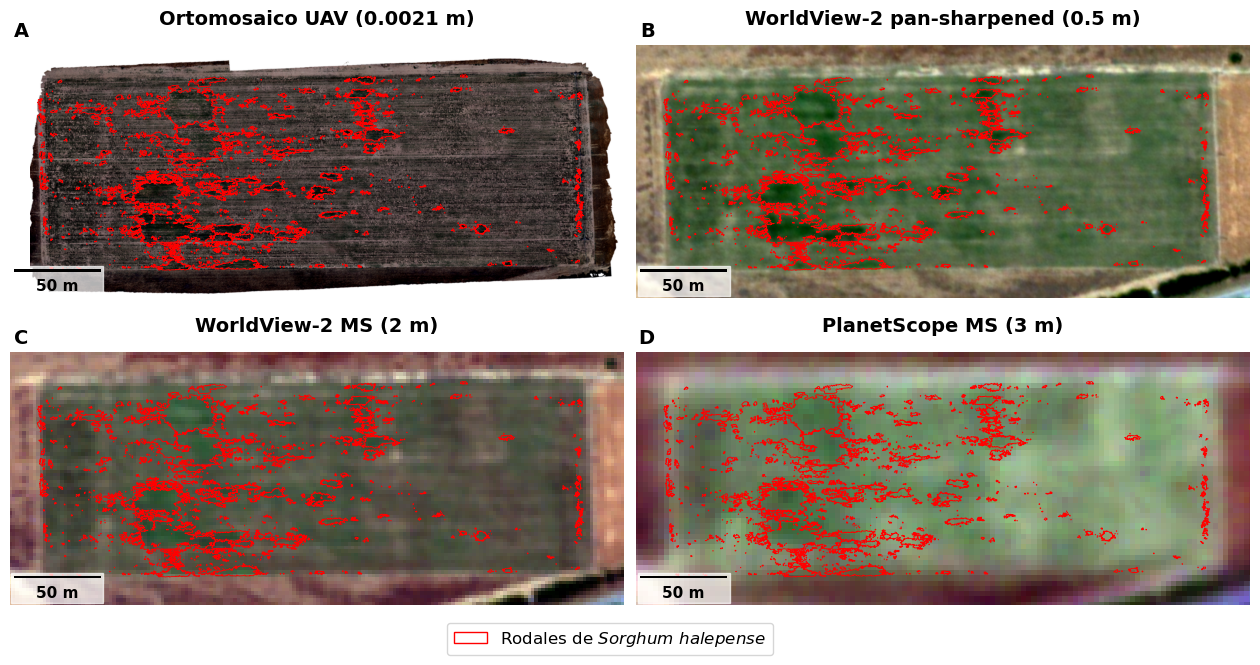

✅ ¡Figura completada y guardada en: 08_resultados/Cuadricula_Parcela_Enmascarada.png!


In [11]:
# =====================================================================
# 1. PREPARACIÓN DE DATOS VECTORIALES (Doble límite)
# =====================================================================
print("🧹 Cargando y reparando shapefiles...")

# --- LÍMITES DE PARCELA ---
gdf_limite_pln = gpd.read_file(shp_bounds)
gdf_limite_pln.geometry = gdf_limite_pln.geometry.make_valid()

gdf_limite_wv2 = gpd.read_file(shp_bounds_wv2)
gdf_limite_wv2.geometry = gdf_limite_wv2.geometry.make_valid()

print("✅ Todos los Shapefiles (Límites y Rodales) listos.")

# =====================================================================
# 2. MOTOR DE TRATAMIENTO ESPECTRAL
# =====================================================================
def realce_color_boa(arr, pmin=2, pmax=98):
    """Estiramiento de contraste rápido. Ignora los valores 0."""
    arr_nulo = arr == 0
    arr_out = np.zeros_like(arr, dtype=np.float32)
    for i in range(arr.shape[0]):
        banda = arr[i]
        b_valida = banda[banda > 0]
        if len(b_valida) == 0: continue
        vmin, vmax = np.percentile(b_valida, (pmin, pmax))
        if vmax == vmin: vmax += 1e-5
        banda_estirada = np.clip((banda - vmin) / (vmax - vmin), 0, 1)
        arr_out[i] = banda_estirada
    arr_out[arr_nulo] = 0
    return arr_out

# =====================================================================
# 3. MOTOR GRÁFICO (Rotación Física Sin Enmascarado de Límites)
# =====================================================================
def generar_cuadricula_ultra_rapida(dict_imagenes, angulo_rotacion=-30, buffer_visual=15):
    print("🎨 Generando cuadrícula enmascarada con rotación física sin máscara de límites...")
    
    # 1. CÁLCULO DINÁMICO DEL ASPECT RATIO DE LA PARCELA ROTADA
    # Usamos la primera imagen como referencia de la geometría
    primera_config = list(dict_imagenes.values())[0]
    gdf_limite_ref = primera_config['gdf_limite']
    minx_ref, miny_ref, maxx_ref, maxy_ref = gdf_limite_ref.total_bounds
    cx_ref = (minx_ref + maxx_ref) / 2
    cy_ref = (miny_ref + maxy_ref) / 2
    
    # Rotamos la referencia y calculamos dimensiones
    gdf_limite_rot_ref = gdf_limite_ref.rotate(angulo_rotacion, origin=(cx_ref, cy_ref))
    rot_xmin_ref, rot_ymin_ref, rot_xmax_ref, rot_ymax_ref = gdf_limite_rot_ref.total_bounds
    ancho_zoom = (rot_xmax_ref - rot_xmin_ref) + 2 * buffer_visual
    alto_zoom = (rot_ymax_ref - rot_ymin_ref) + 2 * buffer_visual
    aspect_ratio = ancho_zoom / alto_zoom
    
    # 2. DETERMINAR TAMAÑO DE LIENZO PROPORCIONAL
    fig_width = 16
    # La altura se adapta proporcionalmente + espacio para títulos y leyenda (aprox 1.2 pulgadas)
    fig_height = (fig_width / aspect_ratio) + 1.2
    
    # Creamos subplots con espacio (wspace/hspace) muy reducido
    fig, axes = plt.subplots(2, 2, figsize=(fig_width, fig_height), facecolor='white',
                             gridspec_kw={'hspace': 0.05, 'wspace': 0.02})
    axes = axes.flatten()
    
    patch_rojo = mpatches.Patch(edgecolor='red', facecolor='none', 
                                label=r'Rodales de $\it{Sorghum\ halepense}$', linewidth=1.0)
    letras_subfiguras = ['A', 'B', 'C', 'D']
    
    for idx, (titulo, config) in enumerate(dict_imagenes.items()):
        ax = axes[idx]
        ruta_raster = config['ruta']
        bandas_rgb = config['rgb']
        gdf_rodales = config['gdf_rodales']
        gdf_limite = config['gdf_limite']
        
        # Centroide geográfico para la rotación vectorial y del ráster
        minx, miny, maxx, maxy = gdf_limite.total_bounds
        cx = (minx + maxx) / 2
        cy = (miny + maxy) / 2
        
        # Leemos con un buffer mayor para evitar recortes en la rotación
        buffer_lectura = buffer_visual * 4
        p_xmin, p_ymin = minx - buffer_lectura, miny - buffer_lectura
        p_xmax, p_ymax = maxx + buffer_lectura, maxy + buffer_lectura
        
        with rasterio.open(ruta_raster) as src:
            window = from_bounds(p_xmin, p_ymin, p_xmax, p_ymax, src.transform)
            window = window.intersection(rasterio.windows.Window(0, 0, src.width, src.height))
            
            win_xmin, win_ymin, win_xmax, win_ymax = rasterio.windows.bounds(window, src.transform)
            win_w, win_h = int(window.width), int(window.height)
            
            # --- CÁLCULO DE DIMENSIONES DE SALIDA ---
            MAX_DIM = 2000  
            if win_w > MAX_DIM or win_h > MAX_DIM:
                if win_w > win_h:
                    final_w = MAX_DIM
                    final_h = int(win_h * (MAX_DIM / win_w))
                else:
                    final_h = MAX_DIM
                    final_w = int(win_w * (MAX_DIM / win_h))
            else:
                final_h, final_w = win_h, win_w

            # Transformación espacial local
            final_transform = rasterio.transform.from_bounds(win_xmin, win_ymin, win_xmax, win_ymax, final_w, final_h)
            
            # Lectura de la imagen
            if win_w > MAX_DIM or win_h > MAX_DIM:
                out_image = src.read(
                    [int(b) for b in bandas_rgb],
                    window=window,
                    out_shape=(len(bandas_rgb), final_h, final_w),
                    resampling=Resampling.bilinear
                )
            else:
                out_image = src.read([int(b) for b in bandas_rgb], window=window)
            
            bands, real_h, real_w = out_image.shape

            # Aplicar realce espectral BOA
            arr_estirado = realce_color_boa(out_image)
            img_plot = reshape_as_image(arr_estirado)
            
            # --- ROTACIÓN EN ESPACIO DE DATOS ---
            # 1. Calculamos el centro de rotación en píxeles usando la inversa del transform.
            col_c, row_c = ~final_transform * (cx, cy)
            
            # 2. Rotamos la imagen usando el centro exacto en píxeles (rellenando solo las esquinas rotadas con blanco)
            M = cv2.getRotationMatrix2D((col_c, row_c), angulo_rotacion, 1.0)
            img_rot = cv2.warpAffine(img_plot, M, (real_w, real_h), flags=cv2.INTER_LINEAR, 
                                     borderMode=cv2.BORDER_CONSTANT, borderValue=(1.0, 1.0, 1.0))
            
            # 3. Rotamos las geometrías vectoriales usando GeoPandas
            gdf_limite_rot = gdf_limite.rotate(angulo_rotacion, origin=(cx, cy))
            gdf_rodales_rot = gdf_rodales.rotate(angulo_rotacion, origin=(cx, cy))
            
            # Graficamos el ráster rotado
            ax.imshow(img_rot, extent=[win_xmin, win_xmax, win_ymin, win_ymax], origin='upper')
            
            # Graficamos los límites de parcela y rodales rotados
            gdf_limite_rot.plot(ax=ax, color='none', edgecolor='#00b4d8', linewidth=2.5, linestyle='--')
            
            # Dibujamos las líneas rojas de los rodales más finas (linewidth=0.6)
            gdf_rodales_rot.plot(ax=ax, color='none', edgecolor='red', linewidth=0.6)
            
            # 4. Hacemos zoom exacto utilizando los límites de la geometría rotada
            rot_xmin, rot_ymin, rot_xmax, rot_ymax = gdf_limite_rot.total_bounds
            ax.set_xlim(rot_xmin - buffer_visual, rot_xmax + buffer_visual)
            ax.set_ylim(rot_ymin - buffer_visual, rot_ymax + buffer_visual)
            
            # Escala métrica
            escala = ScaleBar(1, units="m", location="lower left", box_alpha=0.7, font_properties={'weight':'bold', 'size':11})
            ax.add_artist(escala)
            
            ax.set_title(titulo, fontsize=14, fontweight='bold', pad=15)
            ax.axis('off')
            # [NUEVO] Etiqueta (A, B, C o D) dentro del bucle y movida al margen superior derecho de cada imagen
            ax.text(0.03, 1.02, letras_subfiguras[idx], transform=ax.transAxes, 
                    fontsize=14, fontweight='bold', va='bottom', ha='right')

    # Leyenda única de rodales pegada a la parte inferior
    fig.legend(handles=[patch_rojo], loc='lower center', ncol=1, fontsize=12, frameon=True, bbox_to_anchor=(0.5, 0.06))
    
    # Ajustamos márgenes de la figura completa
    plt.tight_layout(rect=[0, 0.12, 1, 0.7])
    
    os.makedirs("08_resultados", exist_ok=True)
    ruta_salida = "08_resultados/Cuadricula_Parcela_Enmascarada.png"
    plt.savefig(ruta_salida, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✅ ¡Figura completada y guardada en: {ruta_salida}!")

# =====================================================================
# 4. CONFIGURACIÓN Y EJECUCIÓN
# =====================================================================
imagenes_a_procesar = {

    "Ortomosaico UAV (0.0021 m)": {
        "ruta": ortho_path, 
        "rgb": [1, 2, 3], 
        "gdf_rodales": gdf_pln_limpio,
        "gdf_limite": gdf_limite_pln
    },

    "WorldView-2 pan-sharpened (0.5 m)": {
        "ruta": pansharp_GS, 
        "rgb": [5, 3, 2], 
        "gdf_rodales": gdf_wv2_limpio,
        "gdf_limite": gdf_limite_wv2
    },

    "WorldView-2 MS (2 m)": {
        "ruta": out_ms_wv2, 
        "rgb": [5, 3, 2], 
        "gdf_rodales": gdf_wv2_limpio,
        "gdf_limite": gdf_limite_wv2
    },

    "PlanetScope MS (3 m)": {
        "ruta": out_pln, 
        "rgb": [6, 4, 2], 
        "gdf_rodales": gdf_pln_limpio,
        "gdf_limite": gdf_limite_pln
    } 
}

generar_cuadricula_ultra_rapida(imagenes_a_procesar, angulo_rotacion=-30, buffer_visual=15)
